In [2]:
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"tips: {tips.shape[0]} wierszy, {tips.shape[1]} kolumn")

tips: 244 wierszy, 8 kolumn


In [3]:
lotniska = pd.DataFrame({
'miasto': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Katowice',
'Poznań', 'Rzeszów', 'Łódź', 'Szczecin', 'Bydgoszcz'],
'kod': ['WAW', 'KRK', 'GDN', 'WRO', 'KTW',
'POZ', 'RZE', 'LCJ', 'SZZ', 'BZG'],
'pasazerowie_mln': [18.9, 9.3, 5.7, 3.8, 5.4,
2.6, 0.9, 0.3, 0.6, 0.4],
'linie': [85, 42, 35, 28, 32, 22, 12, 5, 8, 6],
'region': ['Mazowieckie', 'Małopolskie', 'Pomorskie', 'Dolnośląskie',
'Śląskie',
'Wielkopolskie', 'Podkarpackie', 'Łódzkie', 'Zachodniopomorskie',
'Kujawsko-Pomorskie']
})
lotniska.index = lotniska['kod']
print(lotniska[['miasto', 'pasazerowie_mln', 'linie', 'region']])

        miasto  pasazerowie_mln  linie              region
kod                                                       
WAW   Warszawa             18.9     85         Mazowieckie
KRK     Kraków              9.3     42         Małopolskie
GDN     Gdańsk              5.7     35           Pomorskie
WRO    Wrocław              3.8     28        Dolnośląskie
KTW   Katowice              5.4     32             Śląskie
POZ     Poznań              2.6     22       Wielkopolskie
RZE    Rzeszów              0.9     12        Podkarpackie
LCJ       Łódź              0.3      5             Łódzkie
SZZ   Szczecin              0.6      8  Zachodniopomorskie
BZG  Bydgoszcz              0.4      6  Kujawsko-Pomorskie


Zadania
1a — iloc (pozycja):

In [4]:
# 1. Wyświetl 3 pierwsze lotniska (iloc)
print(lotniska.iloc[0:3])
# 2. Wyświetl lotniska od 5. do 8. (pozycje 4-7), tylko kolumny 0 i 2
print(lotniska.iloc[4:8,[0,2]])
# 3. Wyświetl co drugie lotnisko od końca (iloc[::-2])
print(lotniska.iloc[::-2])

       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
       miasto  pasazerowie_mln
kod                           
KTW  Katowice              5.4
POZ    Poznań              2.6
RZE   Rzeszów              0.9
LCJ      Łódź              0.3
        miasto  kod  pasazerowie_mln  linie              region
kod                                                            
BZG  Bydgoszcz  BZG              0.4      6  Kujawsko-Pomorskie
LCJ       Łódź  LCJ              0.3      5             Łódzkie
POZ     Poznań  POZ              2.6     22       Wielkopolskie
WRO    Wrocław  WRO              3.8     28        Dolnośląskie
KRK     Kraków  KRK              9.3     42         Małopolskie


1b — loc (etykieta/warunek):

In [5]:
# 1. Wyświetl dane lotniska KRK (loc po etykiecie)
print(lotniska.loc['KRK'])
# 2. Wyświetl miasto i liczbę linii dla WAW, GDN i KTW (loc z listą etykiet)
print(lotniska.loc[['WAW','GDN','KTW'],['miasto','linie']])
# 3. Lotniska z więcej niż 5 mln pasażerów — które to? (loc + warunek)
print(lotniska.loc[lotniska['pasazerowie_mln']>5])
# 4. Lotniska z mniej niż 20 liniami — wyświetl miasto i region (loc + warunek + kolumny)
print(lotniska.loc[lotniska['linie']<20,['miasto','region']])

miasto                  Kraków
kod                        KRK
pasazerowie_mln            9.3
linie                       42
region             Małopolskie
Name: KRK, dtype: object
       miasto  linie
kod                 
WAW  Warszawa     85
GDN    Gdańsk     35
KTW  Katowice     32
       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
KTW  Katowice  KTW              5.4     32      Śląskie
        miasto              region
kod                               
RZE    Rzeszów        Podkarpackie
LCJ       Łódź             Łódzkie
SZZ   Szczecin  Zachodniopomorskie
BZG  Bydgoszcz  Kujawsko-Pomorskie


1c — łączone:

In [6]:
# 1. Ile lotnisk jest w regionach zaczynających się na literę "M"?
print(lotniska[lotniska['region'].str.startswith('M')].shape[0])
# 2. Oblicz stosunek pasażerów do linii (pasazerowie_mln / linie * 1000000)
# Wyświetl TOP-3 lotniska z najwyższym obłożeniem per linia
stosunek = lotniska['pasazerowie_mln']/lotniska['linie']*1000000
print(stosunek.sort_values(axis=0,ascending=False).head(3))

2
kod
WAW    222352.941176
KRK    221428.571429
KTW    168750.000000
dtype: float64


Runda 1 — Proste filtry:

In [21]:
# "Ile rachunków mieliśmy w piątek?"
print(tips[tips['day'].str.startswith('Fri')].shape[0])
# "Ile rachunków złożyły grupy 1-osobowe? A 6-osobowe?"
print(f'1-osobowe: {tips[tips['size']==1].shape[0]}')
print(f'6-osobowe: {tips[tips['size']==6].shape[0]}')
# "Jaki jest najwyższy rachunek od kobiety?"
print(f'Najwyższy rachunek: {tips[tips['sex']=='Female']['total_bill'].max()}')

19
1-osobowe: 4
6-osobowe: 4
Najwyższy rachunek: 44.3


Runda 2 — Łączone warunki (AND, OR):

In [30]:
# "Ilu niepalących mężczyzn jadło u nas obiad w weekend?"
# (sex == Male) & (smoker == No) & (time == Dinner) & (day isin Sat/Sun)
print(tips[(tips['sex'] == 'Male') & (tips['smoker'] == 'No') & (tips['time'] == 'Dinner') & (tips['day'].isin(['Sat','Sun']))].shape[0])
# "Podaj średni rachunek dla dużych grup (4+) w czwartek."
print(f'średni rachunek: {tips[tips['size']>= 4]['total_bill'].mean()}')
# "Ilu klientów dało napiwek powyżej 25% przy rachunku poniżej 10$?"
# To są podejrzanie hojni — sprawdź czy to nie błędy w danych.
print(tips[(tips['tip'] / tips['total_bill'] > 0.25) & (tips['total_bill'] < 10)].shape[0])

75
średni rachunek: 29.31217391304348
4


Runda 3 — isin, between, query:

In [33]:
# "Rachunki z weekendu (Sat, Sun) w zakresie 15-30$ — ile ich jest?"
# Użyj isin + between w jednym filtrze.
print(len(tips[tips['day'].isin(['Sat', 'Sun']) & tips['total_bill'].between(15, 30)]))

# "Przepisz powyższy filtr używając query() — co jest czytelniejsze?"
print(len(tips.query("day in ['Sat', 'Sun'] and 15 <= total_bill <= 30")))
# Bonus: "Ile rachunków od niepalących mężczyzn na obiedzie przekracza średnią?"
# srednia = tips['total_bill'].mean()
# Użyj query z @srednia
print(len(tips.query("sex == 'Male' and smoker == 'No' and time == 'Lunch' and total_bill > @tips.total_bill.mean()")))



93
93
7


## Ćwiczenie 3: Analiza filmów

In [35]:
import pandas as pd
import numpy as np

filmy = pd.DataFrame({
    'tytul': ['Incepcja', 'Parasite', 'Avengers: Endgame', 'Joker', 'Coco',
              'Get Out', 'Dune', 'Whiplash', 'Mad Max: Fury Road', 'Spider-Man: No Way Home',
              'The Batman', 'Everything Everywhere', 'Oppenheimer', 'Barbie', 'La La Land',
              'Blade Runner 2049', 'Knives Out', '1917', 'Jojo Rabbit', 'Midsommar'],
    'rok': [2010, 2019, 2019, 2019, 2017,
            2017, 2021, 2014, 2015, 2021,
            2022, 2022, 2023, 2023, 2016,
            2017, 2019, 2019, 2019, 2019],
    'gatunek': ['Sci-Fi', 'Thriller', 'Akcja', 'Dramat', 'Animacja',
                'Horror', 'Sci-Fi', 'Dramat', 'Akcja', 'Akcja',
                'Akcja', 'Sci-Fi', 'Dramat', 'Komedia', 'Musical',
                'Sci-Fi', 'Kryminał', 'Wojenny', 'Komedia', 'Horror'],
    'budzet_mln': [160, 11, 356, 55, 175,
                   4.5, 165, 3.3, 150, 200,
                   185, 25, 100, 145, 30,
                   150, 40, 95, 14, 9],
    'przychod_mln': [836, 258, 2798, 1074, 807,
                     255, 407, 49, 380, 1916,
                     771, 141, 952, 1442, 447,
                     259, 311, 384, 90, 48],
    'ocena_imdb': [8.8, 8.5, 8.4, 8.4, 8.4,
                   7.7, 8.0, 8.5, 8.1, 8.2,
                   7.8, 7.8, 8.3, 6.8, 8.0,
                   8.0, 7.9, 8.3, 7.9, 7.1]
})
filmy['roi'] = (filmy['przychod_mln'] / filmy['budzet_mln']).round(1)
print(filmy[['tytul', 'gatunek', 'budzet_mln', 'przychod_mln', 'roi', 'ocena_imdb']])

                      tytul   gatunek  budzet_mln  przychod_mln   roi  \
0                  Incepcja    Sci-Fi       160.0           836   5.2   
1                  Parasite  Thriller        11.0           258  23.5   
2         Avengers: Endgame     Akcja       356.0          2798   7.9   
3                     Joker    Dramat        55.0          1074  19.5   
4                      Coco  Animacja       175.0           807   4.6   
5                   Get Out    Horror         4.5           255  56.7   
6                      Dune    Sci-Fi       165.0           407   2.5   
7                  Whiplash    Dramat         3.3            49  14.8   
8        Mad Max: Fury Road     Akcja       150.0           380   2.5   
9   Spider-Man: No Way Home     Akcja       200.0          1916   9.6   
10               The Batman     Akcja       185.0           771   4.2   
11    Everything Everywhere    Sci-Fi        25.0           141   5.6   
12              Oppenheimer    Dramat       100.0  

3a: Eksploracja i rankingi

In [ ]:
# 1. TOP-5 filmów wg przychodu
print(filmy.nlargest(5, 'przychod_mln')[['tytul', 'przychod_mln']])

# 2. TOP-5 filmów wg ROI — czy to te same filmy?
print(filmy.nlargest(5, 'roi')[['tytul', 'roi']])

# 3. 5 filmów z najwyższą oceną IMDB
print(filmy.nlargest(5, 'ocena_imdb')[['tytul', 'ocena_imdb']])

# 4. Filmy z budżetem poniżej 15 mln$
print(filmy.loc[filmy['budzet_mln'] < 15, ['tytul', 'budzet_mln', 'przychod_mln', 'roi']])

TOP-5 wg przychodu:
                      tytul  przychod_mln
2         Avengers: Endgame          2798
9   Spider-Man: No Way Home          1916
13                   Barbie          1442
3                     Joker          1074
12              Oppenheimer           952

TOP-5 wg ROI:
         tytul   roi
5      Get Out  56.7
1     Parasite  23.5
3        Joker  19.5
14  La La Land  14.9
7     Whiplash  14.8

TOP-5 wg oceny IMDB:
               tytul  ocena_imdb
0           Incepcja         8.8
1           Parasite         8.5
7           Whiplash         8.5
2  Avengers: Endgame         8.4
3              Joker         8.4

Filmy z budżetem < 15 mln$:
          tytul  budzet_mln  przychod_mln   roi
1      Parasite        11.0           258  23.5
5       Get Out         4.5           255  56.7
7      Whiplash         3.3            49  14.8
18  Jojo Rabbit        14.0            90   6.4
19    Midsommar         9.0            48   5.3


3b: Pytania dyrektora

In [38]:
# 1. Ile filmów Akcja? Średni ROI?
akcja = filmy[filmy['gatunek'] == 'Akcja']
print(f'Filmy Akcja: {akcja.shape[0]}, średni ROI: {akcja["roi"].mean():.1f}')

# 2. Perełki: ocena >= 8.0 I budżet < 50 mln$
perelki = filmy[(filmy['ocena_imdb'] >= 8.0) & (filmy['budzet_mln'] < 50)]
print(perelki[['tytul', 'budzet_mln', 'ocena_imdb', 'roi']])

# 3. Średni ROI per gatunek
for gatunek in filmy['gatunek'].unique():
    sr_roi = filmy[filmy['gatunek'] == gatunek]['roi'].mean()
    print(f'  {gatunek}: {sr_roi:.1f}')

# 4. Filmy z lat 2019-2023 z ROI > 5
print(nowe_hity[['tytul', 'rok', 'roi', 'ocena_imdb']])
# Wniosek: niskobudżetowe filmy jak Parasite dają fenomenalny zwrot

Filmy Akcja: 4, średni ROI: 6.0
         tytul  budzet_mln  ocena_imdb   roi
1     Parasite        11.0         8.5  23.5
7     Whiplash         3.3         8.5  14.8
14  La La Land        30.0         8.0  14.9
  Sci-Fi: 3.8
  Thriller: 23.5
  Akcja: 6.0
  Dramat: 14.6
  Animacja: 4.6
  Horror: 31.0
  Komedia: 8.2
  Musical: 14.9
  Kryminał: 7.8
  Wojenny: 4.0
                      tytul   rok   roi  ocena_imdb
1                  Parasite  2019  23.5         8.5
2         Avengers: Endgame  2019   7.9         8.4
3                     Joker  2019  19.5         8.4
9   Spider-Man: No Way Home  2021   9.6         8.2
11    Everything Everywhere  2022   5.6         7.8
12              Oppenheimer  2023   9.5         8.3
13                   Barbie  2023   9.9         6.8
16               Knives Out  2019   7.8         7.9
18              Jojo Rabbit  2019   6.4         7.9
19                Midsommar  2019   5.3         7.1


3c: Łańcuch operacji (chaining)

In [39]:
# TOP-3 filmy wg ROI, z oceną >= 7.5, tylko tytuł, gatunek, ROI i ocena
wynik = (filmy
    [filmy['ocena_imdb'] >= 7.5]
    .nlargest(3, 'roi')
    [['tytul', 'gatunek', 'roi', 'ocena_imdb']]
)
print(wynik)

      tytul   gatunek   roi  ocena_imdb
5   Get Out    Horror  56.7         7.7
1  Parasite  Thriller  23.5         8.5
3     Joker    Dramat  19.5         8.4


## Ćwiczenie 4: Segmentacja filmów + wizualizacja

4a: Segmentacja

In [41]:
# Segmentacja wg ROI
filmy['segment'] = np.select(
    [filmy['roi'] > 10, filmy['roi'] > 3],
    ['Hit', 'Zyskowny'],
    default='Przeciętny'
)

# Ile filmów w każdym segmencie?
print(filmy['segment'].value_counts())

# Średnia ocena per segment
print(filmy.groupby('segment')['ocena_imdb'].mean().round(2))

# Które filmy to Hity?
print(filmy[filmy['segment'] == 'Hit'][['tytul', 'budzet_mln', 'roi']].sort_values('roi', ascending=False))

segment
Zyskowny      12
Hit            5
Przeciętny     3
Name: count, dtype: int64
segment
Hit           8.22
Przeciętny    8.03
Zyskowny      7.98
Name: ocena_imdb, dtype: float64
         tytul  budzet_mln   roi
5      Get Out         4.5  56.7
1     Parasite        11.0  23.5
3        Joker        55.0  19.5
14  La La Land        30.0  14.9
7     Whiplash         3.3  14.8


4b: Wizualizacja

Matplotlib is building the font cache; this may take a moment.


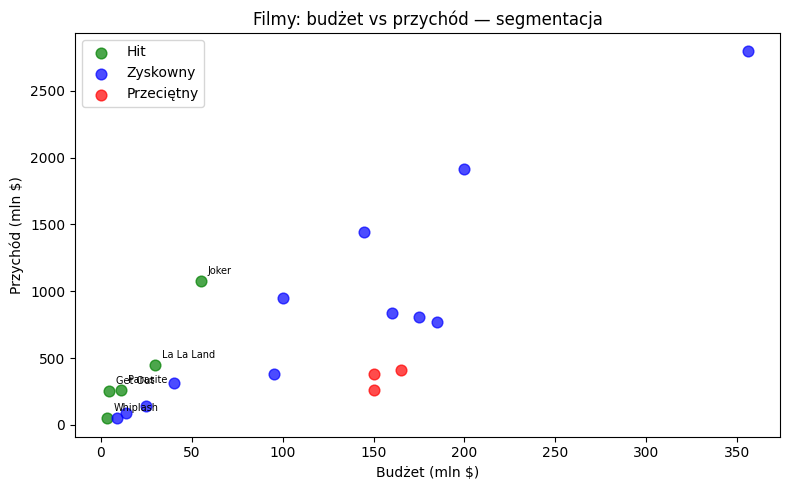

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
kolory = {'Hit': 'green', 'Zyskowny': 'blue', 'Przeciętny': 'red'}
for seg, kolor in kolory.items():
    dane = filmy[filmy['segment'] == seg]
    ax.scatter(dane['budzet_mln'], dane['przychod_mln'],
               c=kolor, label=seg, s=60, alpha=0.7)
    # Dodaj etykiety dla Hitów
    if seg == 'Hit':
        for _, row in dane.iterrows():
            ax.annotate(row['tytul'], (row['budzet_mln'], row['przychod_mln']),
                        textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('Budżet (mln $)')
ax.set_ylabel('Przychód (mln $)')
ax.set_title('Filmy: budżet vs przychód — segmentacja')
ax.legend()
plt.tight_layout()
plt.savefig('filmy_segmentacja.png', dpi=100)
plt.show()

# Pytanie: Czy droższe filmy = wyższy przychód?
# NIE zawsze. Hity (zielone) to głównie tanie filmy z ogromnym zwrotem.
# Avengers to wyjątek — duży budżet I duży przychód, ale ROI niższy niż Get Out.

4c: Wniosek dla dyrektora

In [43]:
# REKOMENDACJA:
# Dane pokazują, że najwyższy ROI osiągają filmy niskobudżetowe z mocnym scenariuszem
# Strategia: 70% budżetu zakupowego przeznaczyć na filmy z mniejszym budzetem czy 50 mln
# Blockbustery (Avengers, Spider-Man) mają dużo widzą, ale ich ROI pomiędzy 5 i 10,
# jest znacznie niższy. Warto kupować 1-2 blockbustery, resztę
# katalogu wypełniać tanimi, wysoko ocenianymi filmami niszowymi.

print('PODSUMOWANIE REKOMENDACJI')
print(f'Hity niskobudżetowe (< 50 mln$, ROI > 10): {filmy[(filmy["budzet_mln"] < 50) & (filmy["roi"] > 10)].shape[0]} filmy')
print(f'Ich średni ROI: {filmy[(filmy["budzet_mln"] < 50) & (filmy["roi"] > 10)]["roi"].mean():.1f}')
print(f'Blockbustery (> 150 mln$) — średni ROI: {filmy[filmy["budzet_mln"] > 150]["roi"].mean():.1f}')

PODSUMOWANIE REKOMENDACJI
Hity niskobudżetowe (< 50 mln$, ROI > 10): 4 filmy
Ich średni ROI: 27.5
Blockbustery (> 150 mln$) — średni ROI: 5.7
